# Policy Gradient Training

In [1]:
import sys
import time
sys.path.append('..')

import gym
import tensorflow as tf
import tensorflow_probability as tfp
import matplotlib.pyplot as plt
from narla.node import Node
from narla.utils import pg_action_loss

### To Do 
* Policy Gradient Training
* Rewards
* Environment
* Steps
* Recordings 

In [2]:
# man = MultiAgentNetwork(input_size=3, num_layers=3)
node = Node()

env = gym.make("CartPole-v1")
state = tf.convert_to_tensor(
    env.reset().reshape(1, -1)
)

node(state)

<tf.Tensor: shape=(1,), dtype=float32, numpy=array([1.], dtype=float32)>

In [3]:
opt = tf.keras.optimizers.Adam(learning_rate=0.01)

def train(states, rewards, actions):
    sum_reward = 0
    discnt_rewards = []
    rewards.reverse()
    for r in rewards:
        sum_reward = r + .99*sum_reward
        discnt_rewards.append(sum_reward)
        
    discnt_rewards.reverse()  

    for state, reward, action in zip(states, discnt_rewards, actions):
        with tf.GradientTape() as tape:
            p = node(state)
            loss = pg_action_loss(p, action, reward)
            
        grads = tape.gradient(loss, node.trainable_variables)
        print(len(grads))
        opt.apply_gradients(zip(grads, node.trainable_variables))

In [10]:
tf.vstack([
    tf.convert_to_tensor([]),
    tf.convert_to_tensor([1,2])
])

AttributeError: module 'tensorflow' has no attribute 'vstack'

In [ ]:
tf.

In [4]:
num_episodes = 500
all_episode_rewards = []
for episode in range(num_episodes):
  
    done = False
    state = tf.convert_to_tensor(
        env.reset().reshape(1, -1)
    )
    total_reward = 0
    rewards = []
    states = []
    actions = []
    
    while not done:
        action = int(node(state).numpy()[0])
        
        next_state, reward, done, _ = env.step(action)
        next_state = tf.convert_to_tensor(
            next_state.reshape(1, -1)
        )
        rewards.append(reward)
        states.append(state)
        actions.append(action)
        
        state = next_state
        total_reward += reward

        if done:
            train(states, rewards, actions)
            #print("total step for this episord are {}".format(t))
            if episode % 25 == 0:
                print(f'Episode: {episode} Reward: {total_reward}')
            
    all_episode_rewards.append(total_reward)

1
1
1
1
0
0
1
0
1
1
1
1
1


InvalidArgumentError: Received a label value of 1 which is outside the valid range of [0, 1).  Label values: 1 [Op:SparseSoftmaxCrossEntropyWithLogits]

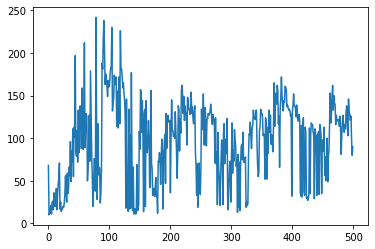

In [5]:
plt.plot(all_episode_rewards)